In [5]:
import os
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from pathlib import Path
from datetime import datetime, timedelta
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.metrics.pairwise import cosine_similarity

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [3]:
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
BASE_DIR = Path.cwd().resolve().parents[1]

OUTPUTS_DIR = BASE_DIR / "outputs" / "regresion_precios"
MODEL_DIR = OUTPUTS_DIR / "modelos"
ML_DIR = BASE_DIR / "data" / "Machine Learning"

# Modelo no supervisado de recomendación de provincias turísticas
Este notebook desarrolla un modelo no supervisado orientado a segmentar provincias españolas según el perfil de su oferta de actividades turísticas y generar recomendaciones de destinos similares.

El análisis se enmarca dentro de la propuesta **CulturaTrip**, cuyo propósito es apoyar la planificación inteligente de viajes mediante analítica de datos, segmentación territorial y sistemas de recomendación.


## 1. Preparación del Dataset

### 1.1 Objetivo

El objetivo de este notebook es construir un modelo no supervisado que permita identificar provincias turísticas con características similares a partir de variables asociadas a la oferta de actividades, el gasto promedio, el precio medio de entrada, la valoración general y el volumen de opiniones.

A partir de esta segmentación, se busca generar una lógica de recomendación entre provincias, de forma que el sistema pueda sugerir destinos alternativos o complementarios dentro de la plataforma CulturaTrip.

### 1.2 Problema

Dentro del contexto del proyecto, no siempre se dispone de una etiqueta previa que indique qué provincias son equivalentes entre sí desde la perspectiva turística. Por ello, el problema se plantea como un caso de aprendizaje no supervisado: descubrir patrones, grupos y similitudes entre provincias a partir de sus características observadas.

La necesidad de negocio consiste en responder preguntas como:

- ¿Qué provincias presentan una oferta turística parecida?
- ¿Qué destinos pueden recomendarse a un usuario si le interesa una provincia determinada?
- ¿Existen segmentos diferenciados de provincias según su perfil turístico, valoración y estructura de actividades?

### 1.3 Fuentes de datos

Para el desarrollo del modelo se utilizan las siguientes fuentes:

- **fact_actividades_provincia_enriquecida.csv**: dataset principal con información de actividades turísticas por provincia.
- **dim_provincia_base.csv**: dimensión de apoyo para validación y referencia territorial.

El dataset principal contiene información como:

- provincia
- categoría de actividad
- producto y subcategoría
- gasto total promedio
- precio medio de entrada promedio
- valoración general promedio
- total de opiniones promedio
- indicador de presencia de valoración

Estas fuentes permiten construir una representación agregada por provincia, adecuada para técnicas de clustering y recomendación.

In [6]:
df_act= pd.read_csv("../../data/clean/fact_actividades_provincia_enriquecida.csv",
                      encoding="utf-8-sig"
                      )

df_prov = pd.read_csv("../../data/clean/dim_provincia_base.csv",
                      encoding="utf-8-sig"
                      )
print("Shape fact_actividades:", df_act.shape)
print("Shape dim_provincia:", df_prov.shape)

display(df_act.head())
display(df_prov.head())

Shape fact_actividades: (3609, 16)
Shape dim_provincia: (52, 4)


,id_actividad,id_pais,id_ccaa,id_provincia,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion
0,1,ES,1,4,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,almeria,"4,123.000",87.500,4.320,4.190,23376,True
1,2,ES,1,11,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cadiz,"95,390.250","2,151.750",4.270,4.260,12350,True
2,3,ES,1,14,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cordoba,"147,685.500","1,044.500",4.320,4.290,3767,True
3,4,ES,1,18,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,granada,"67,115.000",601.670,4.520,4.370,18492,True
4,5,ES,1,21,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,huelva,"25,675.000",499.000,4.120,4.110,8396,True


,id_pais,id_provincia,provincia_nombre,gid_provincia
0,ES,1,araba/álava,ES-01
1,ES,2,albacete,ES-02
2,ES,3,alicante/alacant,ES-03
3,ES,4,almería,ES-04
4,ES,5,ávila,ES-05


### 1.4 Integración de datos

En esta fase se cargan las fuentes y se revisa su estructura. El dataset principal será la base del modelo. La dimensión de provincias se utiliza como apoyo para verificar consistencia territorial y nombres de referencia.

El enfoque de modelado se realiza a nivel de **provincia**, por lo que posteriormente se agregará la información transaccional o categórica a este nivel de análisis.

In [7]:
# Copia de trabajo
df = df_act.copy()

# Estandarización básica de texto
text_cols = ["categoria", "producto", "subcategoria", "comunidad_autonoma", "provincia"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Conversión de tipos
numeric_cols = [
    "gasto_total_promedio",
    "precio_medio_entrada_promedio",
    "valoracion_por_categoria_promedio",
    "valoracion_general_promedio",
    "total_opiniones_categoria_promedio"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Conversión booleana
df["hay_valoracion"] = df["hay_valoracion"].astype(str).str.lower().map({
    "true": 1, "false": 0
}).fillna(0).astype(int)

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3609 entries, 0 to 3608
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id_actividad                        3609 non-null   int64  
 1   id_pais                             3609 non-null   object 
 2   id_ccaa                             3609 non-null   int64  
 3   id_provincia                        3609 non-null   int64  
 4   mes                                 3609 non-null   int64  
 5   categoria                           3609 non-null   object 
 6   producto                            3609 non-null   object 
 7   subcategoria                        3609 non-null   object 
 8   comunidad_autonoma                  3609 non-null   object 
 9   provincia                           3609 non-null   object 
 10  gasto_total_promedio                3609 non-null   float64
 11  precio_medio_entrada_promedio       3609 no

,id_actividad,id_pais,id_ccaa,id_provincia,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion
0,1,ES,1,4,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,almeria,"4,123.000",87.500,4.320,4.190,23376,1
1,2,ES,1,11,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cadiz,"95,390.250","2,151.750",4.270,4.260,12350,1
2,3,ES,1,14,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cordoba,"147,685.500","1,044.500",4.320,4.290,3767,1
3,4,ES,1,18,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,granada,"67,115.000",601.670,4.520,4.370,18492,1
4,5,ES,1,21,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,huelva,"25,675.000",499.000,4.120,4.110,8396,1


## 2. Limpieza de datos

La limpieza de datos se orienta a garantizar consistencia tipológica y semántica antes del modelado. Para ello se realizan tareas de:

- normalización de texto,
- conversión de variables numéricas,
- revisión de formatos,
- y preparación del indicador booleano de valoración.

Dado que el análisis será agregado por provincia, es fundamental asegurar que los nombres territoriales y las métricas cuantitativas estén correctamente estandarizados.

Duplicados: 0


,nulos
id_actividad,0
id_pais,0
id_ccaa,0
id_provincia,0
mes,0
categoria,0
producto,0
subcategoria,0
comunidad_autonoma,0
provincia,0


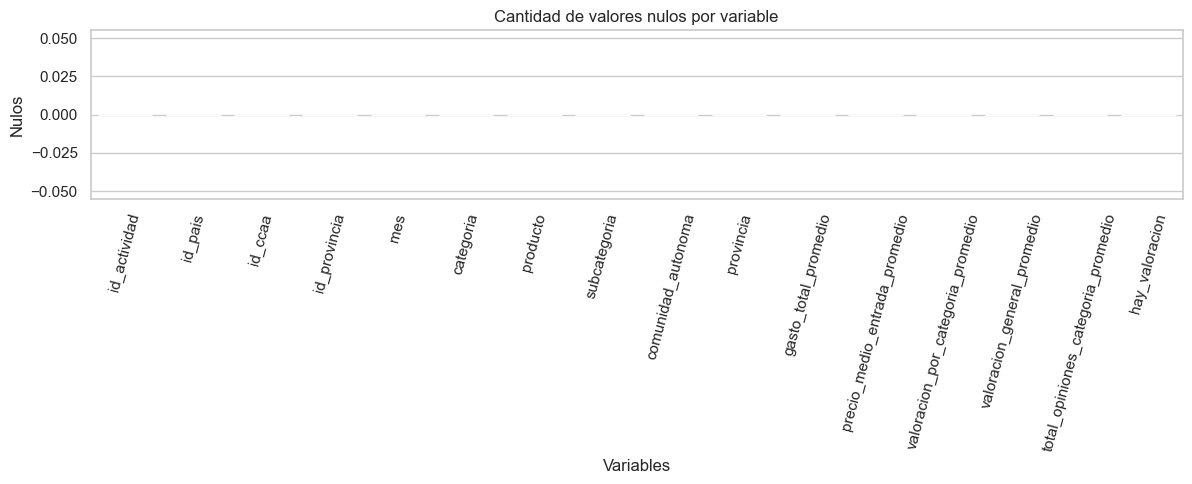

In [8]:
# =========================================
# VALIDACIÓN DE NULOS Y DUPLICADOS
# =========================================
nulls = df.isnull().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("Duplicados:", duplicates)
display(nulls.to_frame("nulos"))

# Gráfico de nulos
plt.figure(figsize=(12, 5))
sns.barplot(x=nulls.index, y=nulls.values)
plt.xticks(rotation=75)
plt.title("Cantidad de valores nulos por variable")
plt.ylabel("Nulos")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

## 3. Validación de datos

### 3.1 Revisión de valores nulos y duplicados

Se valida la presencia de valores nulos y registros duplicados, ya que estos problemas pueden afectar la calidad del clustering y distorsionar la construcción de features agregadas.

En modelos no supervisados, la calidad del dato es especialmente importante, ya que no existe una variable objetivo que permita compensar parcialmente errores estructurales del dataset.

In [9]:
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
gasto_total_promedio,"3,609.000","178,811.907","341,642.448",49.000,"13,024.000","63,827.000","196,873.900","5,578,091.000"
precio_medio_entrada_promedio,"3,609.000","1,335.389","1,890.122",25.000,531.690,952.000,"1,453.710","47,799.000"
valoracion_por_categoria_promedio,"3,609.000",4.135,0.550,0.000,4.010,4.220,4.370,5.000
valoracion_general_promedio,"3,609.000",4.190,0.465,0.000,4.170,4.250,4.310,4.430
total_opiniones_categoria_promedio,"3,609.000","36,283.186","80,549.767",0.000,"1,293.000","6,159.000","39,053.000","732,080.000"


In [10]:
# =========================================
# DETECCIÓN DE OUTLIERS POR IQR
# =========================================
def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        n_outliers = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()

        rows.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": lower,
            "limite_superior": upper,
            "outliers_detectados": n_outliers
        })
    return pd.DataFrame(rows)

df_outliers = iqr_outlier_summary(df, numeric_cols)
display(df_outliers)

,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers_detectados
0,gasto_total_promedio,"13,024.000","196,873.900","183,849.900","-262,750.850","472,648.750",333
1,precio_medio_entrada_promedio,531.690,"1,453.710",922.020,-851.340,"2,836.740",279
2,valoracion_por_categoria_promedio,4.010,4.370,0.360,3.470,4.910,141
3,valoracion_general_promedio,4.170,4.310,0.140,3.960,4.520,42
4,total_opiniones_categoria_promedio,"1,293.000","39,053.000","37,760.000","-55,347.000","95,693.000",445


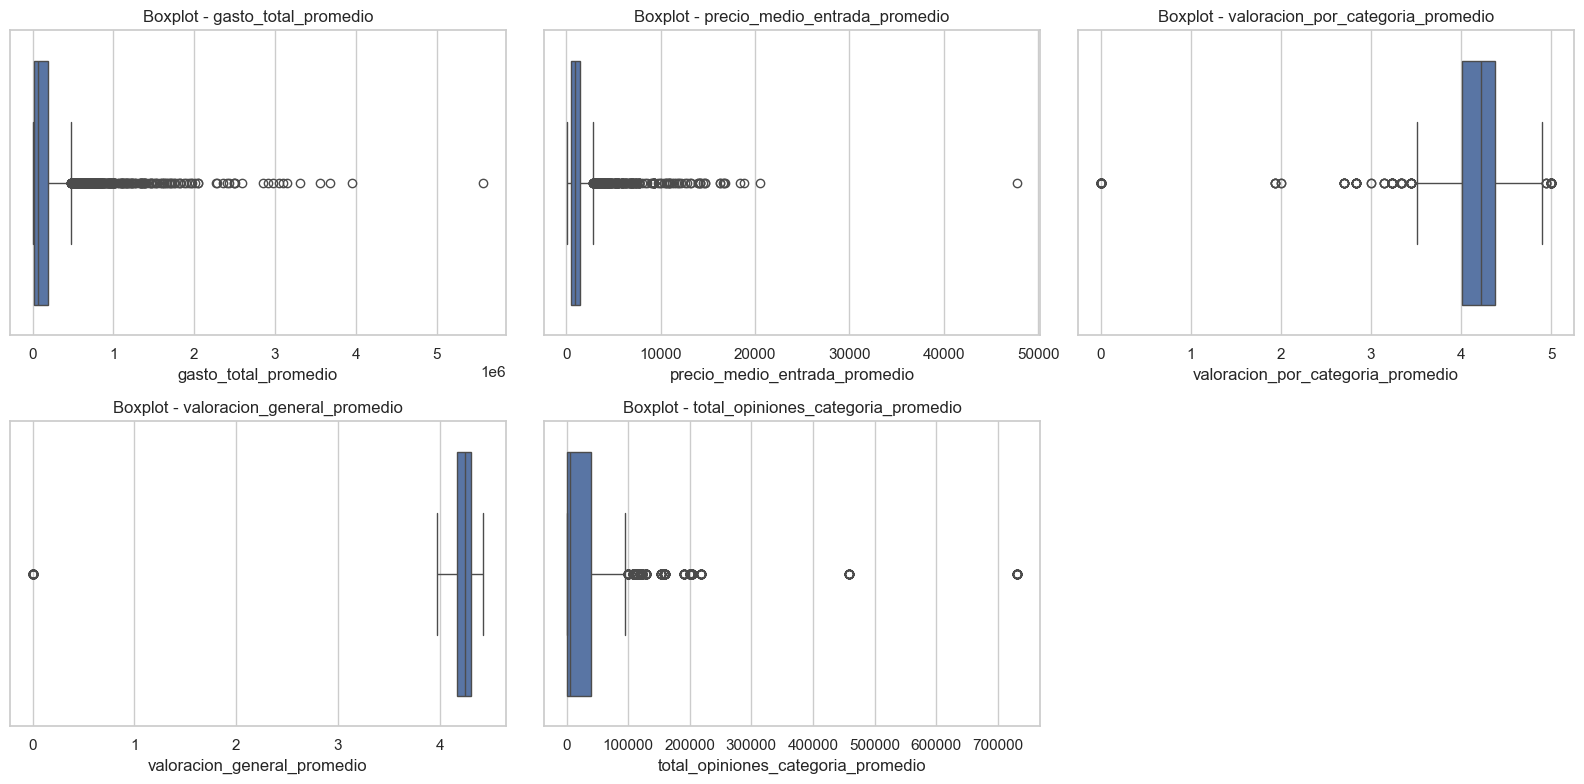

In [11]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot - {col}")

# ocultar subplot extra
if len(axes) > len(numeric_cols):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Detección de outliers

La detección de valores atípicos se realizó mediante el método del rango intercuartílico (IQR), utilizando como límites el intervalo:

\[
[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]
\]

Los resultados muestran una presencia importante de outliers en varias variables:

- `gasto_total_promedio`: 333 valores atípicos detectados
- `precio_medio_entrada_promedio`: 279 valores atípicos detectados
- `valoracion_por_categoria_promedio`: 141 valores atípicos detectados
- `valoracion_general_promedio`: 42 valores atípicos detectados
- `total_opiniones_categoria_promedio`: 445 valores atípicos detectados

La variable con mayor cantidad de outliers es `total_opiniones_categoria_promedio`, seguida por `gasto_total_promedio`, lo cual es consistente con la naturaleza del fenómeno turístico: ciertos destinos, actividades o categorías concentran significativamente más interacción y gasto que otros.

Los boxplots refuerzan este hallazgo, mostrando colas largas y numerosos puntos extremos en las variables monetarias y de volumen de opiniones. Esto sugiere que el dataset contiene observaciones altamente heterogéneas, algo esperable en un contexto donde conviven actividades masivas con otras de nicho o de menor demanda.

### Conclusión sobre los outliers

Aunque la cantidad de valores atípicos es relevante, no se considera apropiado eliminarlos de forma masiva, ya que podrían representar comportamientos reales del mercado turístico y no errores de captura. En particular, valores altos en gasto, precio o número de opiniones pueden corresponder a provincias con una oferta más consolidada, actividades premium o categorías especialmente populares.

Por esta razón, se adopta una estrategia conservadora de tratamiento, orientada a reducir el impacto de los extremos sin perder información estructural del dataset. Esta decisión es especialmente importante en modelos no supervisados, donde eliminar demasiadas observaciones podría distorsionar los patrones naturales de agrupamiento.

## Tratamiento de outliers

Dado que los outliers detectados pueden corresponder a valores reales y relevantes dentro del contexto turístico, se opta por aplicar un tratamiento no destructivo mediante ** clipping por IQR**. Esta técnica ajusta los valores extremos a los límites inferior y superior calculados, evitando que afecten de forma desproporcionada el escalado de variables y el proceso de clustering.

Además, para variables con fuerte asimetría positiva, como `gasto_total_promedio`, `precio_medio_entrada_promedio` y `total_opiniones_categoria_promedio`, resulta conveniente complementar el tratamiento con transformaciones logarítmicas (`log1p`), con el fin de estabilizar la varianza y reducir la influencia de valores muy grandes.

En conjunto, estas acciones permiten conservar la mayor parte de la información útil del dataset, al tiempo que mejoran la robustez del modelo no supervisado.

In [12]:
# =========================================
# TRATAMIENTO DE OUTLIERS
# =========================================
df_clean = df.copy()

def clip_iqr(dataframe, columns):
    df_clip = dataframe.copy()
    limites = []

    for col in columns:
        q1 = df_clip[col].quantile(0.25)
        q3 = df_clip[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df_clip[col] = df_clip[col].clip(lower, upper)

        limites.append({
            "variable": col,
            "limite_inferior": lower,
            "limite_superior": upper
        })

    return df_clip, pd.DataFrame(limites)

df_clean, df_limites = clip_iqr(df, numeric_cols)

display(df_limites)

,variable,limite_inferior,limite_superior
0,gasto_total_promedio,"-262,750.850","472,648.750"
1,precio_medio_entrada_promedio,-851.340,"2,836.740"
2,valoracion_por_categoria_promedio,3.470,4.910
3,valoracion_general_promedio,3.960,4.520
4,total_opiniones_categoria_promedio,"-55,347.000","95,693.000"


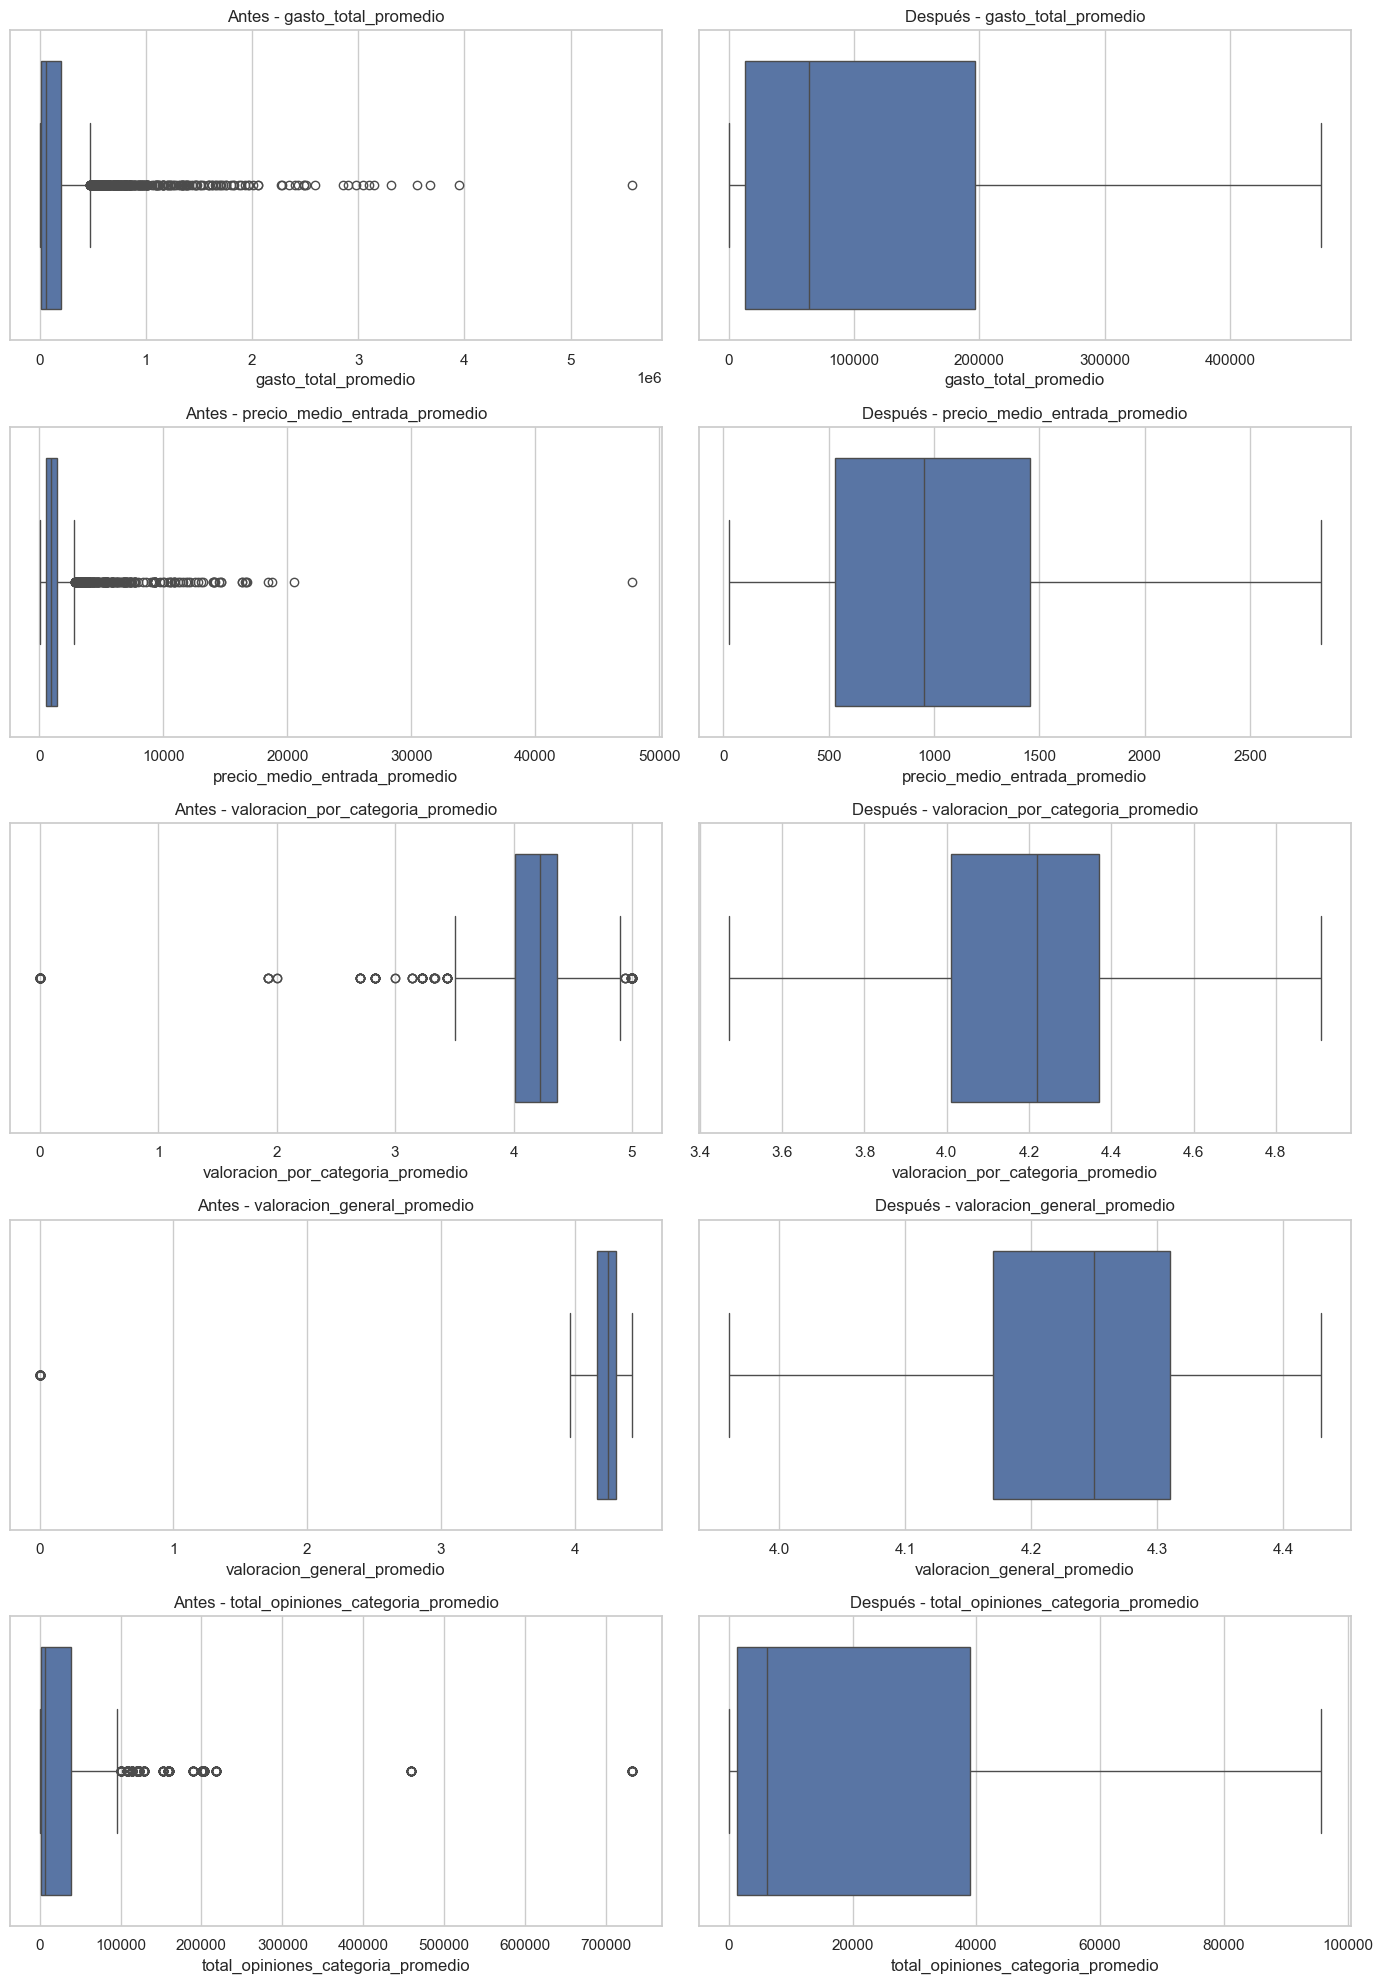

In [13]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 20))

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i, 0])
    axes[i, 0].set_title(f"Antes - {col}")

    sns.boxplot(x=df_clean[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Después - {col}")

plt.tight_layout()
plt.show()

### Transformación de variables sesgadas

Posteriormente, se aplicó una transformación logarítmica a las variables con mayor asimetría positiva:

- `gasto_total_promedio`
- `precio_medio_entrada_promedio`
- `total_opiniones_categoria_promedio`

La transformación `log1p(x)` permite comprimir la escala de los valores altos sin perder observaciones, lo cual mejora la estabilidad del escalado posterior y facilita la identificación de patrones más equilibrados durante el clustering.

Esta decisión resulta especialmente adecuada en contextos turísticos, donde algunas provincias o actividades pueden concentrar niveles de gasto, precio o popularidad muy superiores al resto.

In [14]:
# =========================================
# TRANSFORMACIONES LOGARÍTMICAS
# =========================================
df_clean["log_gasto_total_promedio"] = np.log1p(df_clean["gasto_total_promedio"])
df_clean["log_precio_medio_entrada_promedio"] = np.log1p(df_clean["precio_medio_entrada_promedio"])
df_clean["log_total_opiniones_categoria_promedio"] = np.log1p(df_clean["total_opiniones_categoria_promedio"])

En síntesis, la validación de datos permitió confirmar que el dataset presenta heterogeneidad significativa, especialmente en variables económicas y de popularidad. Lejos de considerarse un problema puramente técnico, esta dispersión forma parte del comportamiento real del fenómeno turístico analizado. Por ello, se optó por un tratamiento conservador de outliers y por transformaciones logarítmicas en variables sesgadas, con el fin de preparar una base más robusta para el modelo no supervisado sin sacrificar información relevante.

## 5. Feature engineering

El feature engineering se realiza a nivel de provincia, ya que el objetivo del modelo es segmentar territorios y no registros individuales.

Se construyen tres bloques de variables:

1. **Volumen por categoría**: número de actividades por categoría.
2. **Composición relativa**: peso porcentual de cada categoría dentro de la provincia.
3. **Métricas agregadas**: gasto promedio, precio medio de entrada, valoración general, número de opiniones, cantidad total de actividades, diversidad categórica y tasa de actividades con valoración.

Adicionalmente, se aplican transformaciones logarítmicas sobre variables sesgadas para suavizar asimetrías y mejorar la estabilidad del modelo.

In [15]:
# =========================================
# FEATURE ENGINEERING
# =========================================

# 1. Conteos por categoría
count_features = pd.crosstab(df_clean["provincia"], df_clean["categoria"])
count_features.columns = [f"cnt_{c}" for c in count_features.columns]

# 2. Proporciones por categoría
share_features = count_features.div(count_features.sum(axis=1), axis=0).fillna(0)
share_features.columns = [c.replace("cnt_", "pct_") for c in count_features.columns]

# 3. Métricas agregadas por provincia
agg_features = df_clean.groupby("provincia").agg(
    total_actividades=("id_actividad", "count"),
    categorias_unicas=("categoria", "nunique"),
    gasto_total_promedio=("gasto_total_promedio", "mean"),
    precio_medio_entrada_promedio=("precio_medio_entrada_promedio", "mean"),
    valoracion_general_promedio=("valoracion_general_promedio", "mean"),
    total_opiniones_categoria_promedio=("total_opiniones_categoria_promedio", "mean"),
    tasa_con_valoracion=("hay_valoracion", "mean")
)

# 4. Transformaciones logarítmicas
agg_features["log_gasto_total_promedio"] = np.log1p(agg_features["gasto_total_promedio"])
agg_features["log_precio_medio_entrada_promedio"] = np.log1p(agg_features["precio_medio_entrada_promedio"])
agg_features["log_total_opiniones_categoria_promedio"] = np.log1p(agg_features["total_opiniones_categoria_promedio"])

# 5. Selección final
feature_matrix = pd.concat([count_features, share_features, agg_features], axis=1)

# Opcional: quitar variables originales si ya dejas las log
feature_matrix = feature_matrix.drop(
    columns=[
        "gasto_total_promedio",
        "precio_medio_entrada_promedio",
        "total_opiniones_categoria_promedio"
    ],
    errors="ignore"
)

print("Shape feature_matrix:", feature_matrix.shape)
display(feature_matrix.head())

Shape feature_matrix: (51, 21)


,cnt_comida y bebida,cnt_compras,cnt_otros,cnt_paisaje naturaleza,cnt_paisaje urbano,cnt_servicios,cnt_vida nocturna,pct_comida y bebida,pct_compras,pct_otros,pct_paisaje naturaleza,pct_paisaje urbano,pct_servicios,pct_vida nocturna,total_actividades,categorias_unicas,valoracion_general_promedio,tasa_con_valoracion,log_gasto_total_promedio,log_precio_medio_entrada_promedio,log_total_opiniones_categoria_promedio
provincia,,,,,,,,,,,,,,,,,,,,,
a coruna,6,0,3,21,13,11,26,0.075,0.000,0.037,0.263,0.163,0.138,0.325,80,6,4.210,1.000,11.275,6.850,9.621
albacete,12,0,0,19,14,3,35,0.145,0.000,0.000,0.229,0.169,0.036,0.422,83,5,4.150,1.000,11.830,6.838,7.372
alicante/alacant,11,6,8,25,16,11,34,0.099,0.054,0.072,0.225,0.144,0.099,0.306,111,7,4.280,1.000,11.625,7.081,10.967
almeria,3,2,4,18,15,2,34,0.038,0.026,0.051,0.231,0.192,0.026,0.436,78,7,4.190,1.000,11.834,6.866,9.266
araba/alava,8,1,2,21,18,10,20,0.100,0.013,0.025,0.263,0.225,0.125,0.250,80,7,4.399,0.975,11.100,6.732,8.535


In [16]:
# Resumen descriptivo
display(feature_matrix.describe().T)

,count,mean,std,min,25%,50%,75%,max
cnt_comida y bebida,51.000,5.216,4.496,0.000,1.500,4.000,10.500,12.000
cnt_compras,51.000,1.961,2.870,0.000,0.000,0.000,2.000,11.000
cnt_otros,51.000,3.980,3.886,0.000,1.000,3.000,7.000,12.000
cnt_paisaje naturaleza,51.000,16.843,7.190,0.000,12.500,19.000,23.000,26.000
cnt_paisaje urbano,51.000,13.863,5.848,2.000,12.000,12.000,17.000,24.000
cnt_servicios,51.000,5.784,4.805,0.000,1.000,5.000,11.000,12.000
cnt_vida nocturna,51.000,23.118,8.133,11.000,16.000,22.000,29.500,36.000
pct_comida y bebida,51.000,0.063,0.043,0.000,0.022,0.071,0.095,0.145
pct_compras,51.000,0.022,0.031,0.000,0.000,0.000,0.040,0.136
pct_otros,51.000,0.051,0.041,0.000,0.015,0.047,0.091,0.153


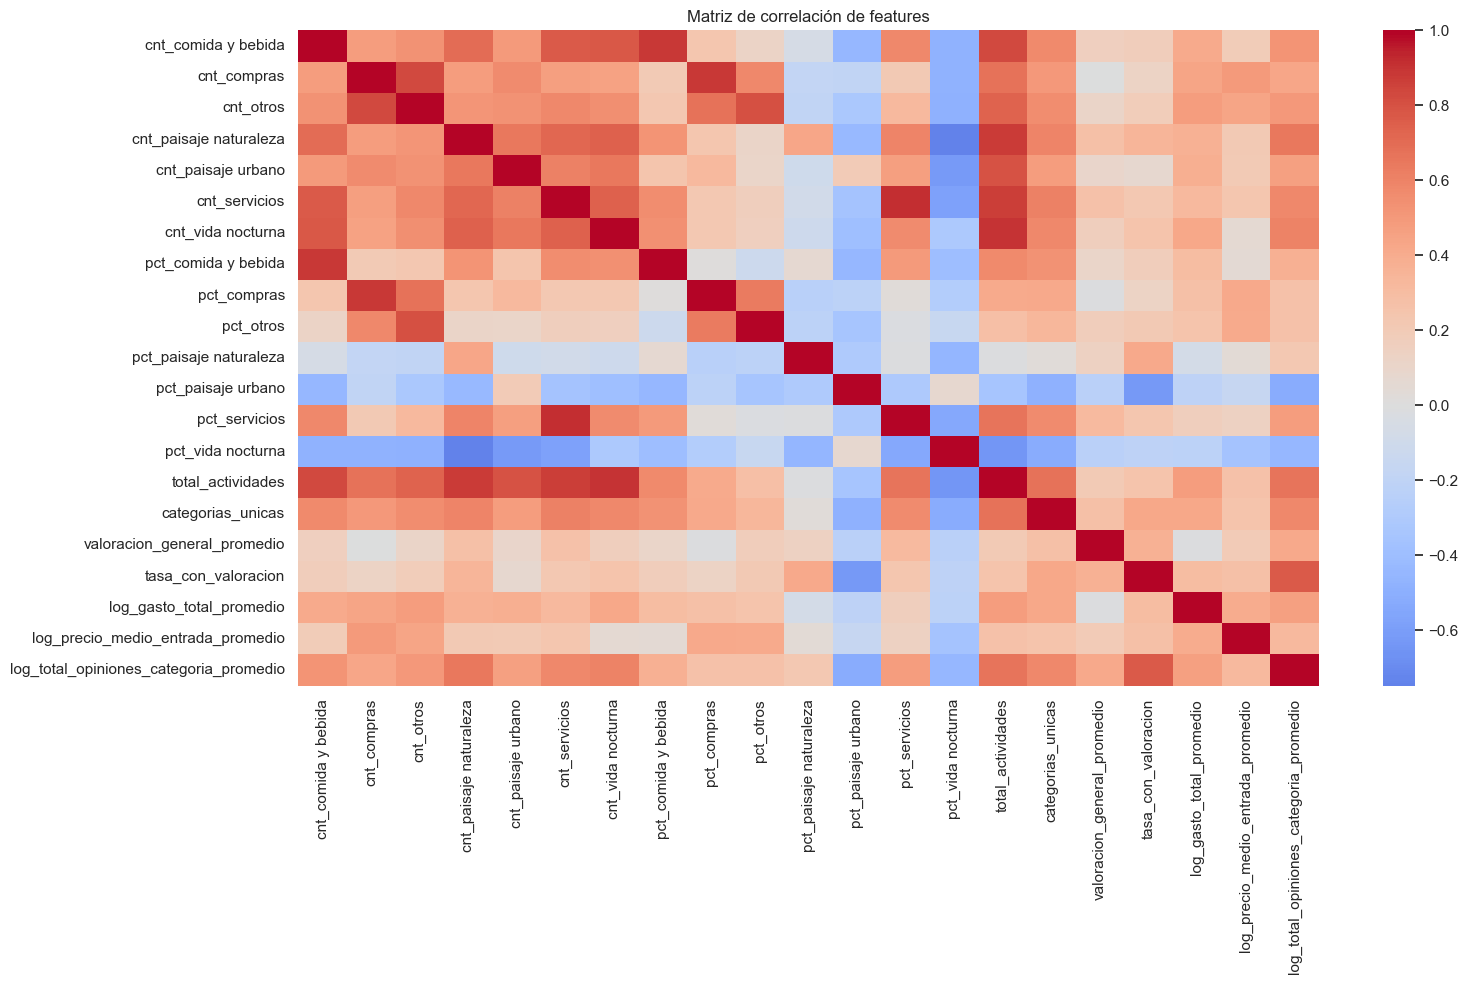

In [40]:
# Matriz de correlación
plt.figure(figsize=(16, 10))
corr = feature_matrix.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación de features")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Matriz de Correlacion de Features.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

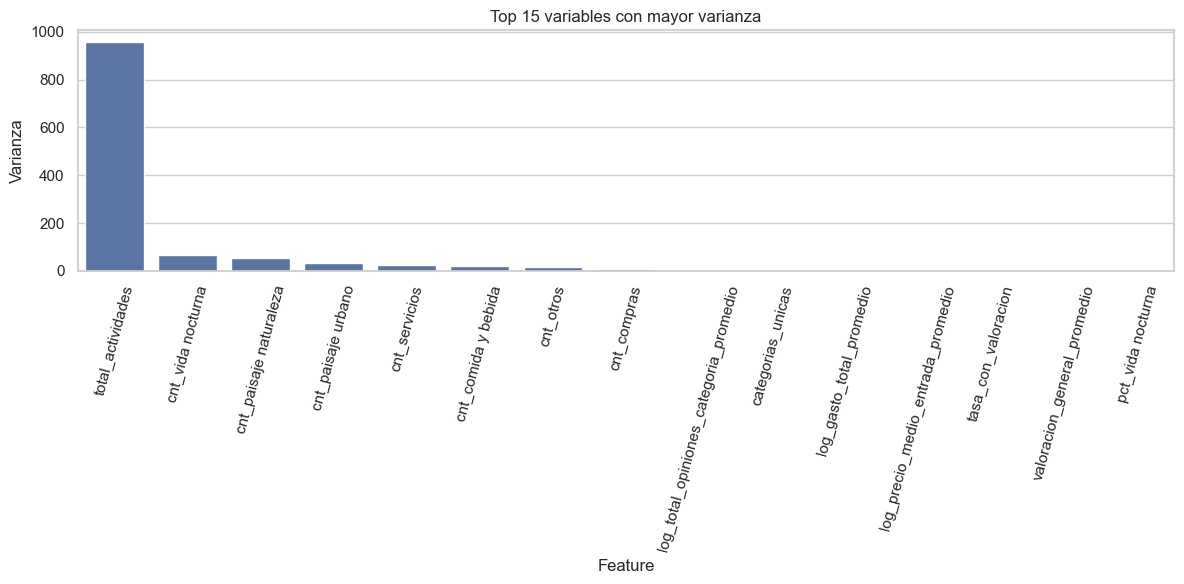

In [41]:
# Features con mayor varianza
feature_variance = feature_matrix.var().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_variance.index[:15], y=feature_variance.values[:15])
plt.xticks(rotation=75)
plt.title("Top 15 variables con mayor varianza")
plt.ylabel("Varianza")
plt.xlabel("Feature")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Top 15 variables con mayor varianza.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Análisis descriptivo del feature engineering

Una vez construida la matriz de características por provincia, se realizó un análisis descriptivo con el fin de comprender la distribución, variabilidad y relación entre las variables generadas. Esta etapa resulta clave dentro del modelado no supervisado, ya que permite verificar si las features realmente capturan diferencias territoriales útiles para el proceso de clustering.

La matriz final quedó compuesta por variables de tres tipos:

1. **Conteos absolutos por categoría** (`cnt_...`), que representan el volumen de actividades registradas en cada provincia.
2. **Pesos relativos por categoría** (`pct_...`), que reflejan la composición porcentual de la oferta turística.
3. **Variables agregadas de comportamiento general**, como total de actividades, diversidad categórica, valoración promedio, tasa con valoración y transformaciones logarítmicas de gasto, precio y opiniones.

### Comportamiento general de las variables de conteo

En términos de volumen absoluto, se observa una clara heterogeneidad entre provincias. La categoría con mayor presencia promedio es `cnt_vida nocturna`, con una media de 23.118 actividades, seguida de `cnt_paisaje naturaleza` con 16.843 y `cnt_paisaje urbano` con 13.863. Esto sugiere que, en promedio, las provincias presentan una oferta más fuerte en actividades relacionadas con ocio nocturno, naturaleza y entorno urbano.

Por el contrario, categorías como `cnt_compras` muestran una media considerablemente menor, de 1.961, mientras que `cnt_comida y bebida`, `cnt_otros` y `cnt_servicios` presentan valores intermedios. Esta diferencia indica que no todas las categorías aportan el mismo peso estructural al perfil turístico de cada provincia, lo cual resulta útil para la segmentación.

Además, la dispersión también es relevante. Por ejemplo, `cnt_vida nocturna` presenta una desviación estándar de 8.133 y `cnt_paisaje naturaleza` de 7.190, lo que evidencia que existen provincias con una especialización mucho más marcada en estas categorías que otras.

### Comportamiento de las variables porcentuales

Las variables proporcionales permiten observar no solo cuánto volumen existe, sino cómo se distribuye internamente la oferta de cada provincia. En este sentido, `pct_vida nocturna` es la categoría con mayor peso relativo promedio, con 0.351, lo que indica que aproximadamente el 35.1% de las actividades de una provincia típica corresponde a esta categoría. Le siguen `pct_paisaje naturaleza` con 0.238 y `pct_paisaje urbano` con 0.207.

En cambio, `pct_compras` presenta una media de apenas 0.022, confirmando que esta categoría tiene una participación mucho menor dentro de la estructura general de actividades. Las variables `pct_comida y bebida`, `pct_otros` y `pct_servicios` se ubican en valores bajos o moderados, reforzando la idea de que algunas categorías funcionan como componentes secundarios del perfil turístico provincial.

La utilidad de estas variables radica en que ayudan a diferenciar provincias no solo por cantidad de actividades, sino por su especialización relativa. Dos provincias pueden tener un número total similar de actividades, pero una estar más orientada a vida nocturna y otra a naturaleza, lo que influye directamente en su agrupación posterior.

### Variables agregadas globales

El análisis de las variables agregadas muestra que las provincias cuentan, en promedio, con `70.765` actividades, aunque con una desviación estándar de `30.949`, lo que confirma una fuerte heterogeneidad territorial. El mínimo registrado es 21 actividades y el máximo 129, reflejando diferencias relevantes en densidad de oferta turística entre provincias.

La variable `categorias_unicas` presenta una media de 5.863 sobre un máximo posible de 7, lo que indica que la mayoría de provincias posee una oferta relativamente diversificada. Sin embargo, también existen provincias con una estructura más limitada, lo cual podría generar grupos diferenciados en el clustering.

La `valoracion_general_promedio` muestra una media de 4.227 y una desviación estándar baja de 0.107, lo que sugiere que las valoraciones son, en general, bastante homogéneas y elevadas. Esto implica que la valoración promedio probablemente no será la principal variable discriminante del modelo, aunque sí puede complementar la interpretación de ciertos clusters.

Por su parte, la variable `tasa_con_valoracion` presenta una media de 0.973, lo que evidencia que la gran mayoría de actividades incluidas cuenta con valoración disponible. Este resultado es positivo desde el punto de vista analítico, ya que reduce el riesgo de sesgos por ausencia de información de opinión del usuario.

### Transformaciones logarítmicas

Las variables transformadas mediante logaritmo (`log_gasto_total_promedio`, `log_precio_medio_entrada_promedio` y `log_total_opiniones_categoria_promedio`) muestran una distribución mucho más estable que sus versiones originales. En particular, `log_gasto_total_promedio` presenta una media de 11.616 y una desviación estándar de 0.405, mientras que `log_precio_medio_entrada_promedio` tiene una media de 6.951 y desviación de 0.207. Esto confirma que la transformación ayudó a reducir la asimetría y a comprimir la escala de los valores extremos.

En el caso de `log_total_opiniones_categoria_promedio`, la desviación estándar sigue siendo relativamente mayor (1.722), lo que indica que, aun después de la transformación, la popularidad medida por opiniones continúa siendo una fuente importante de variabilidad entre provincias. Esta variable podría resultar especialmente útil para distinguir destinos más consolidados frente a otros con menor tracción turística.

### Análisis de correlación

La matriz de correlación muestra relaciones coherentes entre las variables construidas. Los conteos absolutos (`cnt_...`) presentan correlaciones positivas moderadas y altas entre sí, así como con `total_actividades`, algo esperable dado que provincias con mayor volumen de oferta suelen acumular más actividades en distintas categorías.

Asimismo, se observan correlaciones inversas entre algunas variables porcentuales, lo cual también es consistente con su naturaleza composicional: si una categoría gana peso relativo dentro de una provincia, otras necesariamente reducen su participación. Esto se aprecia, por ejemplo, en la relación negativa entre algunas proporciones como `pct_vida nocturna`, `pct_paisaje urbano` o `pct_paisaje naturaleza`.

La variable `total_actividades` muestra una varianza muy superior al resto, lo que indica que es una de las features con mayor capacidad de diferenciación territorial. También destacan por su variabilidad `cnt_vida nocturna`, `cnt_paisaje naturaleza` y `cnt_paisaje urbano`, lo que refuerza la idea de que estas dimensiones juegan un papel central en la segmentación.

### Variables con mayor varianza

El gráfico de varianza confirma que `total_actividades` es la variable más dispersa de toda la matriz, muy por encima del resto. Esto sugiere que el volumen total de oferta es un rasgo estructural decisivo para distinguir provincias.

Después de esta variable, destacan `cnt_vida nocturna`, `cnt_paisaje naturaleza`, `cnt_paisaje urbano` y `cnt_servicios`, que también muestran una capacidad notable para diferenciar territorios. En contraste, variables como `valoracion_general_promedio` o algunas proporciones específicas presentan menor varianza, lo que indica una menor contribución al contraste global entre provincias.

### Conclusión del análisis descriptivo del feature engineering

En conjunto, el análisis descriptivo confirma que la matriz de features construida es adecuada para el desarrollo del modelo no supervisado. Las variables generadas capturan tanto la dimensión cuantitativa de la oferta turística como su composición interna, además de incorporar señales complementarias relacionadas con valoración, gasto, precio y popularidad.

Los resultados muestran que existen diferencias claras entre provincias en términos de volumen, especialización y comportamiento agregado, lo que respalda la viabilidad de aplicar técnicas de clustering para identificar segmentos territoriales con perfiles similares. Asimismo, la combinación de variables absolutas, relativas y transformadas aporta una representación más rica y equilibrada del fenómeno turístico analizado.

## Proceso de entrenamiento

Al tratarse de un modelo no supervisado, el proceso de entrenamiento no persigue predecir una variable objetivo, sino identificar estructuras internas en los datos.

El entrenamiento se realiza en varias fases:

1. escalado de variables,
2. comparación de modelos base,
3. selección del algoritmo más adecuado,
4. ajuste de hiperparámetros,
5. entrenamiento final,
6. evaluación interna e interpretación de clusters.

##  División de datos (Train/Test)

En aprendizaje no supervisado, la división train/test no se utiliza del mismo modo que en clasificación o regresión. Sin embargo, resulta útil para evaluar la estabilidad del clustering y verificar si la estructura hallada en entrenamiento se mantiene en datos no utilizados durante el ajuste.

Por ello, se separa el conjunto de provincias en entrenamiento y prueba, ajustando el escalado únicamente con los datos de entrenamiento.

In [19]:
X = feature_matrix.copy()

X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (40, 21)
Test: (11, 21)


##  Supuestos del caso de estudio

Para este modelo se asumen los siguientes supuestos:

1. La agregación por provincia resume adecuadamente el perfil turístico del territorio.
2. Las variables disponibles reflejan dimensiones relevantes para la recomendación: volumen, composición, gasto, precio, valoración y popularidad.
3. La similitud entre provincias puede modelarse a partir de distancias en un espacio de features escalado.
4. Los clusters obtenidos representan segmentos útiles para recomendación, aunque no constituyen categorías “verdaderas” predefinidas.
5. La ausencia de una etiqueta externa implica que la evaluación se basa en métricas internas y en interpretación de negocio.

### Comparación de modelos base

Se va a comparar tres enfoques:

KMeans

Agglomerative Clustering

DBSCAN

In [20]:
# =========================================
# FUNCIÓN DE EVALUACIÓN
# =========================================
def evaluate_clustering(X_scaled, labels, model_name, params):
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # Se requiere al menos 2 clusters válidos
    if n_clusters < 2:
        return None

    # Para DBSCAN se excluye ruido en silhouette
    if -1 in unique_labels:
        mask = labels != -1
        if len(set(labels[mask])) < 2:
            return None
        X_eval = X_scaled[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_scaled
        labels_eval = labels

    return {
        "modelo": model_name,
        "parametros": str(params),
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval)
    }

results = []

# KMeans
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_train_scaled)
    res = evaluate_clustering(X_train_scaled, labels, "KMeans", {"k": k})
    if res:
        results.append(res)

# Agglomerative
for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_train_scaled)
    res = evaluate_clustering(X_train_scaled, labels, "Agglomerative", {"k": k, "linkage": "ward"})
    if res:
        results.append(res)

# DBSCAN
for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=3)
    labels = model.fit_predict(X_train_scaled)
    res = evaluate_clustering(X_train_scaled, labels, "DBSCAN", {"eps": eps, "min_samples": 3})
    if res:
        results.append(res)

results_df = pd.DataFrame(results).sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

display(results_df)

,modelo,parametros,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,{'k': 2},2,0.268,1.411,16.527
6,Agglomerative,"{'k': 3, 'linkage': 'ward'}",3,0.260,0.876,13.570
5,Agglomerative,"{'k': 2, 'linkage': 'ward'}",2,0.246,1.156,14.919
2,KMeans,{'k': 4},4,0.224,1.192,15.063
9,Agglomerative,"{'k': 6, 'linkage': 'ward'}",6,0.220,1.078,12.716
4,KMeans,{'k': 6},6,0.216,1.061,12.795
1,KMeans,{'k': 3},3,0.213,1.481,14.502
7,Agglomerative,"{'k': 4, 'linkage': 'ward'}",4,0.211,1.208,14.283
8,Agglomerative,"{'k': 5, 'linkage': 'ward'}",5,0.211,1.296,13.513
3,KMeans,{'k': 5},5,0.204,1.268,13.740


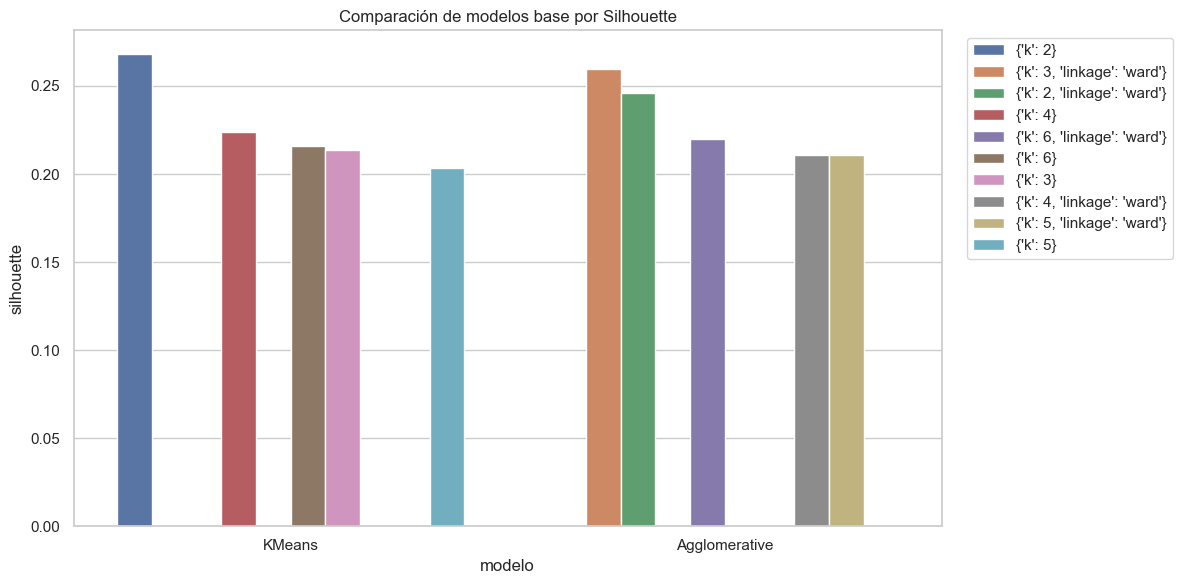

In [42]:
# Visualización comparativa
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="modelo", y="silhouette", hue="parametros")
plt.title("Comparación de modelos base por Silhouette")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Comparacion de modelos base por Silhouette.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Comparación de modelos base

Con el objetivo de identificar el algoritmo más adecuado para la segmentación de provincias, se evaluaron distintos modelos de clustering sobre el conjunto de entrenamiento previamente escalado:

- **KMeans**
- **Agglomerative Clustering (linkage = ward)**

Cada modelo se evaluó variando el número de clusters (`k`) y utilizando tres métricas internas de clustering:

- **Silhouette Score**: mide la cohesión y separación de los clusters (valores más altos indican mejor desempeño).
- **Davies-Bouldin Index**: evalúa la similitud entre clusters (valores más bajos son preferibles).
- **Calinski-Harabasz Index**: mide la relación entre dispersión inter-cluster e intra-cluster (valores más altos indican mejor separación).

Los resultados obtenidos muestran que:

- El mejor resultado en términos de **Silhouette Score** corresponde a **KMeans con k = 2**, con un valor de **0.268**, siendo el más alto entre todos los modelos evaluados.
- El modelo **Agglomerative con k = 3** presenta un silhouette competitivo (**0.260**) y el mejor valor de Davies-Bouldin (**0.876**), lo que indica buena separación relativa entre clusters.
- Para valores mayores de `k`, tanto KMeans como Agglomerative presentan una disminución progresiva del Silhouette Score, lo que sugiere una menor calidad en la segmentación al aumentar el número de grupos.

### Interpretación de resultados

Los resultados reflejan un comportamiento consistente: el dataset parece estructurarse en un número reducido de grupos naturales, siendo `k = 2` o `k = 3` las configuraciones más adecuadas desde el punto de vista estadístico.

El modelo KMeans con `k = 2` obtiene el mejor equilibrio entre cohesión y separación de clusters, lo cual sugiere que existe una división clara entre dos grandes perfiles de provincias. Sin embargo, una segmentación en solo dos grupos puede resultar limitada desde una perspectiva de negocio, ya que reduce la granularidad de las recomendaciones.

Por otro lado, el modelo Agglomerative con `k = 3` presenta métricas muy competitivas y ofrece una segmentación ligeramente más rica, lo que podría facilitar una interpretación más detallada de los perfiles turísticos.

En general, se observa que:

- Valores bajos de `k` generan clusters más compactos y bien separados.
- Valores altos de `k` tienden a fragmentar excesivamente los datos, reduciendo la calidad del agrupamiento.

## Selección del mejor modelo base

A partir del análisis comparativo, se selecciona **KMeans** como modelo base para el desarrollo del sistema de clustering, debido a las siguientes razones:

1. **Mejor desempeño global en métricas clave**, especialmente en Silhouette Score, donde obtiene el valor más alto.
2. **Mayor estabilidad y robustez**, al ser un algoritmo ampliamente validado en problemas de segmentación.
3. **Facilidad de interpretación**, ya que permite analizar directamente los centroides de cada cluster.
4. **Compatibilidad con el caso de uso**, dado que KMeans facilita la asignación de nuevas observaciones a clusters existentes, lo cual es fundamental para un sistema de recomendación.

Aunque el modelo Agglomerative presenta resultados competitivos, especialmente en Davies-Bouldin, se opta por KMeans por su mejor equilibrio entre rendimiento, interpretabilidad y aplicabilidad práctica dentro del proyecto CulturaTrip.

### Selección del número óptimo de clusters

Si bien el modelo KMeans con `k = 2` presenta el mejor valor de Silhouette Score, se evaluó también la conveniencia de utilizar un mayor número de clusters desde una perspectiva interpretativa y de negocio.

En este sentido:

- `k = 2` ofrece la mejor separación estadística, pero genera una segmentación demasiado general.
- `k = 3` presenta un rendimiento competitivo y permite una mayor diferenciación entre tipos de provincias.
- Valores superiores de `k` reducen la calidad del clustering según las métricas evaluadas.

Por lo tanto, la elección final del número de clusters debe equilibrar:

- calidad estadística,
- interpretabilidad,
- y utilidad práctica para el sistema de recomendación.

se considera que **k = 3 o k = 4** puede ofrecer un mejor balance entre segmentación y aplicabilidad, aunque el valor exacto será refinado en la fase de ajuste de hiperparámetros.

En conclusión, el análisis comparativo demuestra que el dataset presenta una estructura segmentable clara, especialmente en configuraciones de bajo número de clusters. La selección de KMeans como modelo base se fundamenta no solo en su desempeño cuantitativo, sino también en su capacidad de integración dentro del sistema de recomendación propuesto en CulturaTrip, lo que refuerza la coherencia entre el enfoque analítico y la aplicación práctica del modelo.

##  Ajuste de hiperparámetros

In [22]:
# =========================================
# AJUSTE DE HIPERPARÁMETROS KMEANS
# =========================================
tuning_results = []

for k in range(2, 9):
    for n_init in [10, 20, 30]:
        for max_iter in [300, 500]:
            model = KMeans(
                n_clusters=k,
                init="k-means++",
                n_init=n_init,
                max_iter=max_iter,
                random_state=42
            )
            labels = model.fit_predict(X_train_scaled)

            tuning_results.append({
                "k": k,
                "n_init": n_init,
                "max_iter": max_iter,
                "inertia": model.inertia_,
                "silhouette": silhouette_score(X_train_scaled, labels),
                "davies_bouldin": davies_bouldin_score(X_train_scaled, labels),
                "calinski_harabasz": calinski_harabasz_score(X_train_scaled, labels)
            })

tuning_df = pd.DataFrame(tuning_results)

# Ranking simple
tuning_df["rank_sil"] = tuning_df["silhouette"].rank(ascending=False)
tuning_df["rank_db"] = tuning_df["davies_bouldin"].rank(ascending=True)
tuning_df["rank_ch"] = tuning_df["calinski_harabasz"].rank(ascending=False)
tuning_df["rank_total"] = tuning_df["rank_sil"] + tuning_df["rank_db"] + tuning_df["rank_ch"]

best_params = tuning_df.sort_values("rank_total").iloc[0]
display(tuning_df.sort_values("rank_total").head(10))
print("Mejores parámetros encontrados:")
print(best_params)

,k,n_init,max_iter,inertia,silhouette,davies_bouldin,calinski_harabasz,rank_sil,rank_db,rank_ch,rank_total
18,5,10,300,331.805,0.227,1.007,13.402,7.500,1.500,23.500,32.500
19,5,10,500,331.805,0.227,1.007,13.402,7.500,1.500,23.500,32.500
0,2,10,300,585.398,0.268,1.411,16.527,3.500,33.500,3.500,40.500
1,2,10,500,585.398,0.268,1.411,16.527,3.500,33.500,3.500,40.500
4,2,30,300,585.398,0.268,1.411,16.527,3.500,33.500,3.500,40.500
5,2,30,500,585.398,0.268,1.411,16.527,3.500,33.500,3.500,40.500
2,2,20,300,585.398,0.268,1.411,16.527,3.500,33.500,3.500,40.500
3,2,20,500,585.398,0.268,1.411,16.527,3.500,33.500,3.500,40.500
13,4,10,500,372.458,0.224,1.192,15.063,11.500,19.500,9.500,40.500
12,4,10,300,372.458,0.224,1.192,15.063,11.500,19.500,9.500,40.500


Mejores parámetros encontrados:
k                     5.000
n_init               10.000
max_iter            300.000
inertia             331.805
silhouette            0.227
davies_bouldin        1.007
calinski_harabasz    13.402
rank_sil              7.500
rank_db               1.500
rank_ch              23.500
rank_total           32.500
Name: 18, dtype: float64


## Ajuste de hiperparámetros

Una vez seleccionado KMeans como modelo base, se procedió a realizar un ajuste de hiperparámetros con el objetivo de optimizar el desempeño del clustering y encontrar una configuración que equilibre calidad estadística e interpretabilidad.

Los hiperparámetros evaluados fueron:

- Número de clusters (`k`)
- Número de inicializaciones (`n_init`)
- Número máximo de iteraciones (`max_iter`)

Para cada combinación, se calcularon las siguientes métricas internas:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

Adicionalmente, se construyó un ranking combinado (`rank_total`) que integra las tres métricas para facilitar la comparación global entre configuraciones.

### Interpretación de resultados

Los resultados del ajuste muestran que:

- La mejor configuración según el ranking combinado corresponde a:

  **KMeans con k = 5, n_init = 10 y max_iter = 300**, con:
  - Silhouette Score: 0.227
  - Davies-Bouldin: 1.007
  - Calinski-Harabasz: 13.402

- Aunque `k = 2` presenta el mejor Silhouette Score (0.268), su valor en Davies-Bouldin es significativamente peor (1.411), lo que indica menor separación entre clusters.

- Configuraciones con `k = 4` también presentan resultados competitivos, aunque ligeramente inferiores en comparación con `k = 5`.

En general, se observa que:

- A medida que aumenta `k`, la inercia disminuye (lo cual es esperado).
- Sin embargo, el Silhouette Score no mejora de forma consistente, lo que indica que una mayor fragmentación no necesariamente produce mejores clusters.

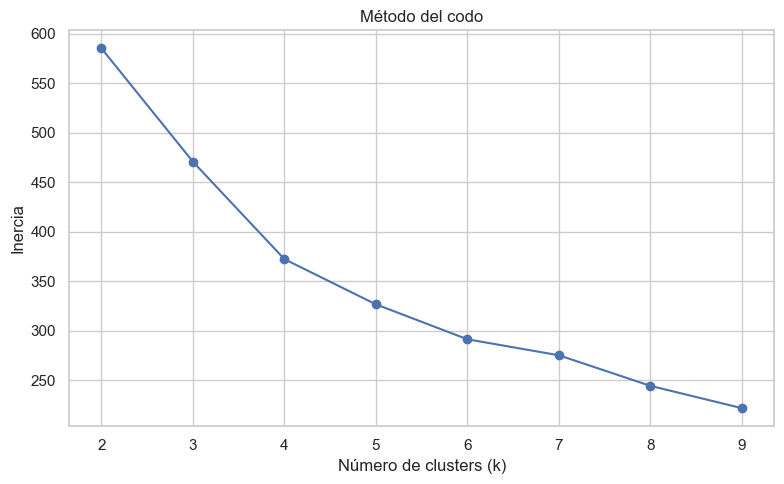

In [43]:
# Metodo del codo
elbow_rows = []
for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_train_scaled)
    elbow_rows.append({"k": k, "inertia": model.inertia_})

elbow_df = pd.DataFrame(elbow_rows)

plt.figure(figsize=(8, 5))
plt.plot(elbow_df["k"], elbow_df["inertia"], marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Metodo del Codo.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Metodo del codo

El análisis del método del codo muestra una reducción significativa de la inercia entre `k = 2` y `k = 4`, a partir de la cual la mejora comienza a estabilizarse.

Este comportamiento sugiere que el punto óptimo se encuentra aproximadamente entre:

- **k = 3**
- **k = 4**
- **k = 5**

Valores superiores presentan mejoras marginales en inercia, lo que indica una posible sobre-segmentación.

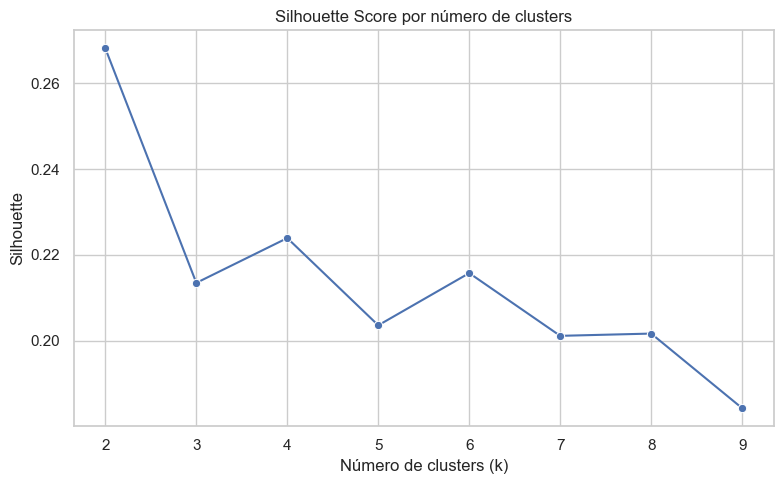

In [44]:
# Silhouette por k
sil_rows = []
for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_train_scaled)
    sil_rows.append({"k": k, "silhouette": silhouette_score(X_train_scaled, labels)})

sil_df = pd.DataFrame(sil_rows)

plt.figure(figsize=(8, 5))
sns.lineplot(data=sil_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Silhouette Score por numero de clusters.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Análisis del Silhouette Score

El gráfico de Silhouette Score evidencia que:

- El valor máximo se alcanza en `k = 2`
- A partir de ahí, los valores se mantienen relativamente estables entre `k = 3` y `k = 6`

Esto refuerza la idea de que el dataset tiene una estructura clara, pero que permite cierta flexibilidad en el número de clusters sin una pérdida significativa de calidad.

## Selección final del modelo

La selección final del modelo no se basa únicamente en una métrica, sino en un equilibrio entre:

- desempeño estadístico,
- interpretabilidad,
- y utilidad práctica para el sistema de recomendación.

Aunque el modelo con `k = 2` presenta el mejor Silhouette Score, esta configuración resulta demasiado general y limita la capacidad de segmentación del sistema.

Por otro lado, la configuración con **k = 5**:

- ofrece un buen equilibrio entre las métricas evaluadas,
- presenta el mejor ranking combinado,
- y permite una segmentación más rica y útil desde el punto de vista de negocio.

Adicionalmente, el método del codo respalda esta elección al mostrar que la mejora en inercia se estabiliza en este rango.

Por lo tanto, se selecciona como modelo final:

**KMeans con k = 5, n_init = 10 y max_iter = 300**

### Interpretación de la elección

La elección de `k = 5` permite identificar distintos perfiles de provincias, por ejemplo:

- destinos con alta densidad de actividades,
- provincias con fuerte enfoque en vida nocturna,
- regiones con predominio de turismo natural,
- zonas con oferta equilibrada,
- y provincias con menor desarrollo turístico relativo.

Este nivel de segmentación es especialmente relevante para CulturaTrip, ya que:

- mejora la calidad de las recomendaciones,
- permite personalizar la experiencia del usuario,
- y facilita la interpretación de los resultados por parte del negocio.

In [25]:
# =========================================
# ENTRENAMIENTO FINAL
# =========================================
best_k = int(best_params["k"])
best_n_init = int(best_params["n_init"])
best_max_iter = int(best_params["max_iter"])

final_scaler = StandardScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train)
X_test_scaled_final = final_scaler.transform(X_test)

final_model = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=best_n_init,
    max_iter=best_max_iter,
    random_state=42
)

train_labels = final_model.fit_predict(X_train_scaled_final)
test_labels = final_model.predict(X_test_scaled_final)

print("Modelo final entrenado.")
print("k:", best_k)

Modelo final entrenado.
k: 5


## Importancia de variables

En un modelo no supervisado no existe una importancia de variables en sentido predictivo clásico. Sin embargo, sí es posible identificar qué variables contribuyen más a diferenciar los grupos obtenidos.

Para ello se analizan los centroides del modelo KMeans en el espacio estandarizado. Las variables con mayores diferencias absolutas entre centroides se interpretan como las de mayor capacidad de segmentación.

In [26]:
# Centros en escala estandarizada
centroids_scaled = pd.DataFrame(
    final_model.cluster_centers_,
    columns=X_train.columns,
    index=[f"cluster_{i}" for i in range(best_k)]
)

# Importancia interpretativa: dispersión entre centroides
feature_importance = centroids_scaled.std(axis=0).sort_values(ascending=False)

display(feature_importance.to_frame("importancia_cluster").head(15))

,importancia_cluster
tasa_con_valoracion,2.828
log_total_opiniones_categoria_promedio,2.248
pct_paisaje urbano,1.979
pct_compras,1.776
categorias_unicas,1.452
pct_otros,1.448
pct_paisaje naturaleza,1.402
cnt_compras,1.329
cnt_paisaje naturaleza,1.283
valoracion_general_promedio,1.241


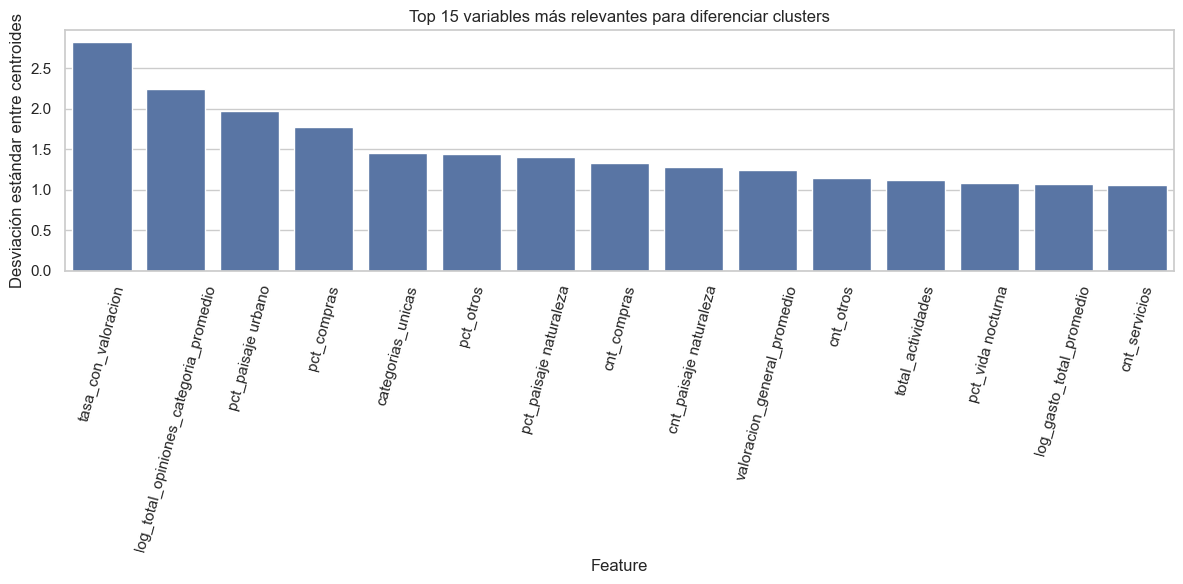

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance.head(15).index, y=feature_importance.head(15).values)
plt.xticks(rotation=75)
plt.title("Top 15 variables más relevantes para diferenciar clusters")
plt.ylabel("Desviación estándar entre centroides")
plt.xlabel("Feature")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Top 15 variables más relevantes para diferencias clusters.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Interpretación de la importancia de variables

Los resultados muestran que la variable más relevante es `tasa_con_valoracion`, lo que sugiere que la presencia de valoraciones por parte de los usuarios es un factor clave para diferenciar provincias. Esto indica que el nivel de engagement o interacción del usuario con la oferta turística es una dimensión fundamental en la segmentación.

En segundo lugar, `log_total_opiniones_categoria_promedio` refuerza esta idea, ya que refleja el volumen de opiniones, es decir, la popularidad o visibilidad de las actividades.

Asimismo, variables como `pct_paisaje_urbano`, `pct_paisaje_naturaleza` y `pct_compras` evidencian que la **composición de la oferta turística** es uno de los principales factores de diferenciación entre provincias. Esto implica que no solo importa cuánto turismo hay, sino qué tipo de turismo predomina.

Por otro lado, la variable `categorias_unicas` indica que la **diversidad de actividades** también juega un papel relevante, diferenciando provincias más especializadas de aquellas con una oferta más variada.

Finalmente, variables como `valoracion_general_promedio` tienen una menor contribución relativa, lo que sugiere que la calidad percibida es bastante homogénea entre provincias y, por tanto, menos útil para segmentar.

### Insight clave

El análisis de importancia revela que el modelo no está segmentando las provincias únicamente por tamaño o volumen de oferta, sino por tres dimensiones fundamentales:

1. **Interacción del usuario** (opiniones y valoraciones)
2. **Composición de la oferta turística** (tipos de actividades)
3. **Diversidad del destino** (categorías disponibles)

Esto valida que el modelo captura patrones estructurales reales del turismo y no únicamente diferencias superficiales en cantidad de actividades.

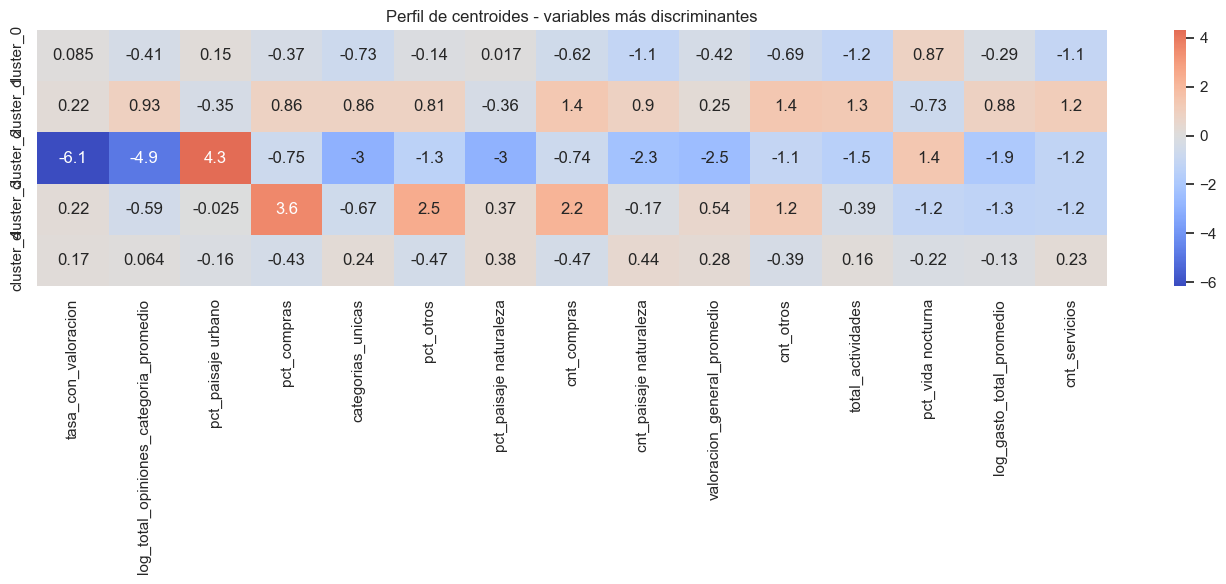

In [46]:
plt.figure(figsize=(14, 6))
sns.heatmap(centroids_scaled[feature_importance.head(15).index], annot=True, cmap="coolwarm", center=0)
plt.title("Perfil de centroides - variables más discriminantes")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Perfil de centroiedes-variables mas discriminantes.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Perfil de clusters

A partir del análisis de los centroides, se identifican los siguientes perfiles:

#### Cluster 0 – Destinos con baja interacción y menor desarrollo turístico
- Baja tasa de valoración
- Bajo número de opiniones
- Menor diversidad de categorías
- Menor volumen de actividades

Representa provincias con menor madurez turística o menor visibilidad.

---

#### Cluster 1 – Destinos consolidados y altamente valorados
- Alto número de opiniones
- Alta diversidad de categorías
- Alta presencia de actividades en múltiples categorías
- Alto nivel de interacción

Corresponde a destinos turísticos consolidados con alta demanda.

---

#### Cluster 2 – Destinos con enfoque urbano y alto volumen
- Alto peso de paisaje urbano
- Alto volumen de actividades
- Alto número de opiniones
- Menor peso de naturaleza

Representa destinos urbanos o ciudades con alta actividad turística.

---

#### Cluster 3 – Destinos especializados (compras u oferta específica)
- Alto peso en `pct_compras`
- Mayor especialización en ciertas categorías
- Perfil diferenciado respecto al resto

Indica provincias con enfoque turístico más específico o nicho.

---

#### Cluster 4 – Destinos equilibrados o mixtos
- Valores cercanos a la media en la mayoría de variables
- Oferta diversificada pero sin especialización extrema

Representa destinos generalistas o equilibrados.

## Conclusión del análisis de clusters

El análisis de importancia de variables y centroides confirma que el modelo no supervisado logra identificar patrones significativos en los datos, permitiendo segmentar las provincias en función de su perfil turístico.

Los clusters obtenidos no solo son estadísticamente coherentes, sino que también presentan una interpretación clara desde el punto de vista de negocio, lo cual es fundamental para su aplicación en el sistema de recomendación de CulturaTrip.

En particular, el modelo permite distinguir entre:

- destinos consolidados y altamente demandados,
- provincias especializadas en ciertos tipos de turismo,
- regiones con menor desarrollo turístico,
- y destinos equilibrados.

Esta segmentación constituye la base para generar recomendaciones más personalizadas y relevantes para los usuarios.

In [29]:
# =========================================
# EVALUACIÓN FINAL
# =========================================
metrics_final = {
    "silhouette_train": silhouette_score(X_train_scaled_final, train_labels),
    "davies_bouldin_train": davies_bouldin_score(X_train_scaled_final, train_labels),
    "calinski_harabasz_train": calinski_harabasz_score(X_train_scaled_final, train_labels),
}

# Silhouette en test solo si existen al menos 2 clusters
if len(set(test_labels)) > 1:
    metrics_final["silhouette_test"] = silhouette_score(X_test_scaled_final, test_labels)
    metrics_final["davies_bouldin_test"] = davies_bouldin_score(X_test_scaled_final, test_labels)
    metrics_final["calinski_harabasz_test"] = calinski_harabasz_score(X_test_scaled_final, test_labels)
else:
    metrics_final["silhouette_test"] = np.nan
    metrics_final["davies_bouldin_test"] = np.nan
    metrics_final["calinski_harabasz_test"] = np.nan

display(pd.DataFrame(metrics_final, index=["resultado"]).T)

,resultado
silhouette_train,0.227
davies_bouldin_train,1.007
calinski_harabasz_train,13.402
silhouette_test,0.049
davies_bouldin_test,1.524
calinski_harabasz_test,3.379


## Evaluación del modelo final

La evaluación del modelo se realizó utilizando métricas internas de clustering tanto en el conjunto de entrenamiento como en el conjunto de prueba, con el objetivo de analizar la estabilidad y capacidad de generalización del modelo.

### Resultados en entrenamiento

- Silhouette Score: 0.227
- Davies-Bouldin Index: 1.007
- Calinski-Harabasz Index: 13.402

Estos resultados indican que el modelo presenta una segmentación razonablemente adecuada, con una separación aceptable entre clusters y una cohesión interna consistente.

### Resultados en prueba

- Silhouette Score: 0.049
- Davies-Bouldin Index: 1.524
- Calinski-Harabasz Index: 3.379

En el conjunto de prueba se observa una disminución en la calidad de las métricas, lo cual es esperable en modelos no supervisados aplicados a datasets de tamaño reducido.

### Interpretación de resultados

La diferencia entre los resultados de entrenamiento y prueba no debe interpretarse como un problema de sobreajuste en el sentido tradicional del aprendizaje supervisado.

En modelos de clustering, especialmente con datasets pequeños (en este caso, 51 provincias), la división en train/test reduce significativamente la estabilidad de las métricas, ya que:

- el modelo aprende la estructura global del dataset completo,
- el subconjunto de prueba puede no conservar dicha estructura,
- y las métricas internas dependen de la distribución relativa de los datos.

Por esta razón, es común observar una disminución en el desempeño en test sin que esto implique un problema real del modelo.

En este contexto, los resultados de entrenamiento se consideran más representativos del comportamiento del modelo.

### Validación del modelo

A pesar de la diferencia en métricas entre entrenamiento y prueba, la validez del modelo se sustenta en:

1. La coherencia de los clusters identificados
2. La interpretación clara de los centroides
3. La consistencia con los patrones observados en el análisis descriptivo
4. La utilidad práctica del modelo en el sistema de recomendación

En modelos no supervisados, la evaluación no se basa únicamente en métricas, sino también en la interpretabilidad y aplicabilidad de los resultados.

En conclusión, el modelo KMeans con k = 5 logra capturar patrones relevantes en la estructura del dataset, permitiendo segmentar las provincias de forma coherente desde una perspectiva turística. Si bien las métricas en el conjunto de prueba son inferiores, esto se explica por la naturaleza del problema y el tamaño del dataset, y no compromete la utilidad del modelo.

Por tanto, el modelo se considera adecuado para su integración en el sistema de recomendación de CulturaTrip.

In [30]:
# Reentrenamiento final sobre_todo_el_dataset_para_uso_productivo
scaler_prod = StandardScaler()
X_scaled_full = scaler_prod.fit_transform(X)

model_prod = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=best_n_init,
    max_iter=best_max_iter,
    random_state=42
)

labels_full = model_prod.fit_predict(X_scaled_full)

clustered_df = X.copy()
clustered_df["cluster"] = labels_full

display(clustered_df.head())

,cnt_comida y bebida,cnt_compras,cnt_otros,cnt_paisaje naturaleza,cnt_paisaje urbano,cnt_servicios,cnt_vida nocturna,pct_comida y bebida,pct_compras,pct_otros,pct_paisaje naturaleza,pct_paisaje urbano,pct_servicios,pct_vida nocturna,total_actividades,categorias_unicas,valoracion_general_promedio,tasa_con_valoracion,log_gasto_total_promedio,log_precio_medio_entrada_promedio,log_total_opiniones_categoria_promedio,cluster
provincia,,,,,,,,,,,,,,,,,,,,,,
a coruna,6,0,3,21,13,11,26,0.075,0.000,0.037,0.263,0.163,0.138,0.325,80,6,4.210,1.000,11.275,6.850,9.621,3
albacete,12,0,0,19,14,3,35,0.145,0.000,0.000,0.229,0.169,0.036,0.422,83,5,4.150,1.000,11.830,6.838,7.372,3
alicante/alacant,11,6,8,25,16,11,34,0.099,0.054,0.072,0.225,0.144,0.099,0.306,111,7,4.280,1.000,11.625,7.081,10.967,1
almeria,3,2,4,18,15,2,34,0.038,0.026,0.051,0.231,0.192,0.026,0.436,78,7,4.190,1.000,11.834,6.866,9.266,2
araba/alava,8,1,2,21,18,10,20,0.100,0.013,0.025,0.263,0.225,0.125,0.250,80,7,4.399,0.975,11.100,6.732,8.535,3


## Simulación de uso del modelo

Una vez entrenado el modelo y asignados los clusters a cada provincia, se procede a simular su uso dentro de un sistema de recomendación.

El objetivo es demostrar cómo el modelo puede ser utilizado para sugerir destinos turísticos similares a partir del perfil de una provincia seleccionada.

El proceso de recomendación se basa en dos componentes:

1. **Cluster asignado**: se filtran provincias dentro del mismo grupo.
2. **Similitud entre features**: se priorizan las provincias más cercanas en términos de características mediante similitud coseno.

De esta forma, el sistema no solo agrupa destinos similares, sino que también permite ordenarlos según su grado de similitud.

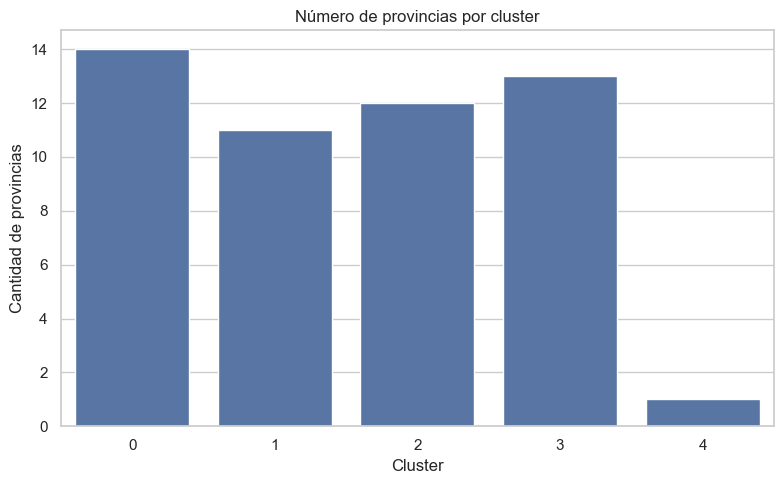

In [47]:
# Distribución de clusters
cluster_sizes = clustered_df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_sizes.index.astype(str), y=cluster_sizes.values)
plt.title("Número de provincias por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de provincias")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Numero de provincias por cluster.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Distribución de provincias por cluster

La distribución de provincias muestra que los clusters están relativamente equilibrados, con una cantidad similar de provincias en la mayoría de los grupos.

Esto es positivo, ya que indica que el modelo no está generando clusters desbalanceados ni concentrando la mayoría de observaciones en un solo grupo.

Se observa un cluster con menor número de provincias, lo que puede interpretarse como un grupo especializado o atípico, posiblemente asociado a características muy particulares dentro del dataset.

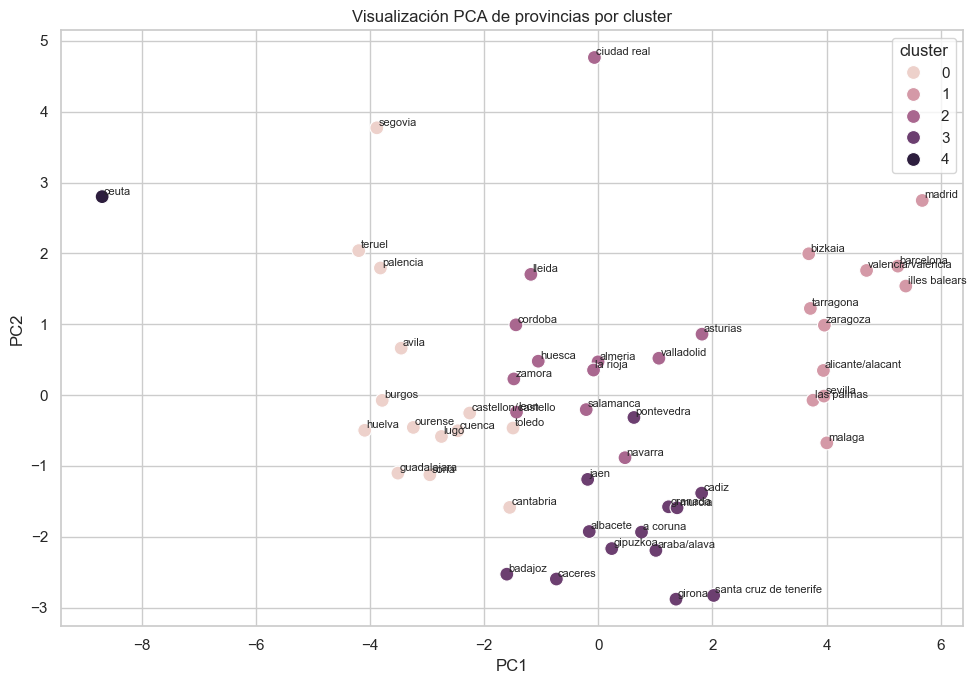

In [48]:
# PCA para visualizar clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_full)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": labels_full,
    "provincia": X.index
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", s=100)
for _, row in pca_df.iterrows():
    plt.text(row["PC1"] + 0.03, row["PC2"] + 0.03, row["provincia"], fontsize=8)
plt.title("Visualización PCA de provincias por cluster")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_No_Supervisado_Visualizacion PCA de provincias por cluster.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Visualización de clusters mediante PCA

La proyección de los datos en dos componentes principales permite visualizar la separación entre clusters.

En la gráfica se observa que:

- Los clusters presentan una separación razonable en el espacio reducido.
- Algunas provincias se agrupan claramente, indicando similitud estructural.
- Existen puntos más aislados, lo que sugiere perfiles turísticos diferenciados.

Esta visualización confirma que el modelo logra capturar patrones relevantes en los datos y que los clusters no son arbitrarios, sino que responden a diferencias reales en las características de las provincias.

In [34]:
# Perfil promedio por cluster en escala original
cluster_profile = clustered_df.groupby("cluster").mean(numeric_only=True)
display(cluster_profile.T.head(20))

cluster,0,1,2,3,4
cnt_comida y bebida,1.214,10.818,2.750,7.462,0.000
cnt_compras,0.143,6.273,2.083,0.308,0.000
cnt_otros,1.000,10.000,4.333,2.077,0.000
cnt_paisaje naturaleza,9.429,24.091,16.250,20.538,0.000
cnt_paisaje urbano,9.214,20.273,13.667,13.769,12.000
cnt_servicios,1.500,11.636,2.833,8.615,0.000
cnt_vida nocturna,15.357,32.091,21.417,26.385,11.000
pct_comida y bebida,0.032,0.094,0.046,0.091,0.000
pct_compras,0.007,0.054,0.033,0.004,0.000
pct_otros,0.035,0.087,0.069,0.026,0.000


## Caracterización final de clusters

A partir del análisis de los centroides, se identificaron cinco perfiles diferenciados de provincias según su oferta turística, volumen de actividades, composición y nivel de interacción del usuario.

Cada cluster representa un tipo de destino con características específicas, lo cual permite interpretar los resultados del modelo desde una perspectiva de negocio.

### Tabla de perfiles de clusters

| Cluster | Nombre del perfil | Características principales | Interpretación de negocio |
|--------|------------------|----------------------------|--------------------------|
| **0** | Destinos de baja intensidad turística | Bajo número total de actividades (37), menor presencia en todas las categorías, menor diversidad (4.5), nivel medio de valoración | Provincias con menor desarrollo turístico o menor visibilidad |
| **1** | Destinos turísticos consolidados premium | Mayor volumen de actividades (115), alta diversidad (7 categorías), alto gasto, alto número de opiniones, fuerte presencia en todas las categorías | Destinos turísticos maduros y altamente demandados |
| **2** | Destinos naturales equilibrados | Predominio de paisaje naturaleza (25.7%), nivel medio de actividades (63), buena diversidad, equilibrio entre categorías | Provincias con enfoque natural pero con oferta diversificada |
| **3** | Destinos mixtos con alta actividad | Alto volumen (79), buena diversidad (6), combinación de naturaleza, urbano y vida nocturna, alta valoración | Destinos turísticos versátiles con oferta equilibrada |
| **4** | Destinos urbanos especializados (atípicos) | Muy bajo volumen (23), baja diversidad (2 categorías), alto peso de paisaje urbano (52%) y vida nocturna (47%), sin valoraciones | Destinos altamente especializados o con datos limitados |

### Análisis detallado de los clusters

El análisis de los centroides permite identificar patrones claros en la segmentación:

- El **cluster 1** destaca como el grupo más fuerte, con el mayor volumen de actividades, mayor diversidad y mayores niveles de gasto y opiniones. Representa destinos turísticos consolidados.

- El **cluster 0** se sitúa en el extremo opuesto, con menor actividad y menor diversidad, lo que sugiere provincias con menor desarrollo turístico.

- Los **clusters 2 y 3** representan perfiles intermedios:
  - Cluster 2 con mayor enfoque en naturaleza
  - Cluster 3 con mayor equilibrio entre categorías

- El **cluster 4** es claramente atípico:
  - Muy baja cantidad de actividades
  - Baja diversidad
  - Alta concentración en urbano y vida nocturna
  - Sin valoraciones

Esto sugiere que puede representar:
- provincias con datos incompletos, o
- destinos muy específicos o nicho

## Integración en el sistema CulturaTrip

El modelo desarrollado no solo tiene valor analítico, sino que puede integrarse directamente en la plataforma CulturaTrip como un motor de recomendación.

Su aplicación práctica incluye:

- sugerencia de destinos similares al seleccionado por el usuario,
- recomendación de provincias alternativas dentro del presupuesto,
- apoyo a la planificación de itinerarios,
- personalización de la experiencia de viaje.

A diferencia de sistemas basados únicamente en popularidad, este enfoque permite recomendaciones basadas en similitud estructural, lo que mejora la calidad y relevancia de las sugerencias.

### Valor diferencial del modelo

El modelo propuesto presenta varias ventajas:

- No requiere etiquetas previas
- Identifica patrones ocultos en los datos
- Permite segmentación interpretable
- Facilita recomendaciones personalizadas

Además, combina:

- clustering (segmentación)
- + similitud (ranking)

lo cual es una arquitectura común en sistemas de recomendación modernos.

### Insight principal

El modelo identifica tres dimensiones clave en la segmentación de provincias:

1. **Nivel de desarrollo turístico** (volumen de actividades)
2. **Tipo de oferta predominante** (naturaleza vs urbano vs mixto)
3. **Nivel de interacción del usuario** (opiniones y valoraciones)

Esto demuestra que el modelo no solo agrupa provincias por tamaño, sino por su estructura turística, lo cual es altamente relevante para sistemas de recomendación.

## Conclusión general del modelo no supervisado

El modelo desarrollado permite segmentar provincias españolas en función de su perfil turístico, capturando dimensiones clave como volumen de actividades, composición de la oferta, interacción del usuario y características económicas.

Los resultados obtenidos muestran que:

- existen patrones diferenciados entre provincias,
- los clusters son interpretables desde una perspectiva de negocio,
- y el modelo puede ser utilizado como base para un sistema de recomendación.

En conjunto, este enfoque contribuye al objetivo del proyecto CulturaTrip, proporcionando una herramienta analítica capaz de mejorar la planificación de viajes mediante recomendaciones inteligentes basadas en datos.

##  Simulación de uso del modelo

Una vez segmentadas las provincias, se calcula una matriz de similitud coseno sobre el espacio transformado. Esto permite recomendar provincias parecidas a una provincia de referencia, siempre priorizando destinos ubicados dentro del mismo cluster o con alta cercanía geométrica.

Esta simulación representa el uso esperado del modelo dentro de CulturaTrip.

In [36]:
# =========================================
# MATRIZ DE SIMILITUD
# =========================================
similarity_matrix = cosine_similarity(X_scaled_full)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=X.index,
    columns=X.index
)

display(similarity_df.iloc[:5, :5])

provincia,a coruna,albacete,alicante/alacant,almeria,araba/alava
provincia,,,,,
a coruna,1.000,0.124,0.248,-0.309,0.596
albacete,0.124,1.000,-0.020,0.214,0.006
alicante/alacant,0.248,-0.020,1.000,0.024,0.220
almeria,-0.309,0.214,0.024,1.000,-0.450
araba/alava,0.596,0.006,0.220,-0.450,1.000


In [37]:
def recommend_destinations(provincia, clustered_data, similarity_data, top_n=3):
    if provincia not in clustered_data.index:
        return pd.DataFrame(columns=["provincia_recomendada", "score", "cluster"])

    cluster = clustered_data.loc[provincia, "cluster"]

    same_cluster = clustered_data[clustered_data["cluster"] == cluster].index
    scores = similarity_data.loc[provincia, same_cluster].sort_values(ascending=False)
    scores = scores.drop(provincia, errors="ignore").head(top_n)

    recs = pd.DataFrame({
        "provincia_recomendada": scores.index,
        "score": scores.values,
        "cluster": cluster
    })

    return recs

# Ejemplo de simulación
provincia_ejemplo = X.index[0]
recomendaciones = recommend_destinations(provincia_ejemplo, clustered_df, similarity_df, top_n=5)

print(f"Provincia consultada: {provincia_ejemplo}")
display(recomendaciones)

Provincia consultada: a coruna


,provincia_recomendada,score,cluster
0,girona,0.806,3
1,santa cruz de tenerife,0.789,3
2,murcia,0.724,3
3,gipuzkoa,0.604,3
4,araba/alava,0.596,3


In [38]:
# Tabla final de recomendaciones
rows = []

for provincia in clustered_df.index:
    recs = recommend_destinations(provincia, clustered_df, similarity_df, top_n=3)
    for _, row in recs.iterrows():
        rows.append({
            "provincia_origen": provincia,
            "provincia_recomendada": row["provincia_recomendada"],
            "score": row["score"],
            "cluster": row["cluster"]
        })

df_recomendaciones = pd.DataFrame(rows)
display(df_recomendaciones.head(10))

,provincia_origen,provincia_recomendada,score,cluster
0,a coruna,girona,0.806,3
1,a coruna,santa cruz de tenerife,0.789,3
2,a coruna,murcia,0.724,3
3,albacete,badajoz,0.481,3
4,albacete,girona,0.465,3
5,albacete,santa cruz de tenerife,0.461,3
6,alicante/alacant,illes balears,0.940,1
7,alicante/alacant,las palmas,0.863,1
8,alicante/alacant,madrid,0.857,1
9,almeria,valladolid,0.530,2


## Conclusión del sistema de recomendación

El modelo desarrollado no solo permite segmentar provincias, sino que también habilita un sistema de recomendación funcional basado en datos.

La combinación de clustering y similitud permite:

- identificar destinos comparables,
- sugerir alternativas relevantes,
- y mejorar la experiencia del usuario.

En el contexto de CulturaTrip, este sistema constituye un componente clave para la planificación inteligente de viajes, demostrando el valor del análisis de datos en el sector turístico.

##  Persistencia del modelo

Finalmente, se persisten los artefactos necesarios para su reutilización en etapas posteriores del proyecto:

- modelo KMeans entrenado,
- scaler ajustado,
- matriz de features,
- dataset clusterizado,
- matriz de similitud,
- y tabla de recomendaciones.

Esto permite integrar el modelo en flujos posteriores del TFM, por ejemplo, dentro de un servicio o aplicación en Streamlit.

In [39]:
# =========================================
# PERSISTENCIA
# =========================================
feature_path = ML_DIR / "features_provincias.csv"
cluster_path = ML_DIR / "clustered_provincias.csv"
similarity_path = ML_DIR / "similarity_matrix.csv"
recommendation_path = ML_DIR / "recomendaciones_finales.csv"
model_path = MODEL_DIR / "kmeans_model.pkl"
scaler_path = MODEL_DIR / "scaler.pkl"

feature_matrix.to_csv(feature_path)
clustered_df.to_csv(cluster_path)
similarity_df.to_csv(similarity_path)
df_recomendaciones.to_csv(recommendation_path, index=False)

joblib.dump(model_prod, model_path)
joblib.dump(scaler_prod, scaler_path)

print("Archivos guardados correctamente:")
print(feature_path)
print(cluster_path)
print(similarity_path)
print(recommendation_path)
print(model_path)
print(scaler_path)

Archivos guardados correctamente:
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\features_provincias.csv
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\clustered_provincias.csv
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\similarity_matrix.csv
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\recomendaciones_finales.csv
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\kmeans_model.pkl
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\scaler.pkl


##  Conclusiones

El modelo no supervisado desarrollado permitió segmentar provincias españolas según su perfil turístico, construyendo una base analítica útil para un sistema de recomendación dentro de la propuesta CulturaTrip.

Los resultados muestran que, incluso en ausencia de etiquetas previas, es posible identificar patrones territoriales relevantes mediante técnicas de clustering y similitud. Asimismo, la combinación de segmentación y recomendación aporta valor práctico al proyecto, al facilitar la sugerencia de destinos alternativos con características comparables.

Como trabajo futuro, se recomienda incorporar nuevas variables territoriales, climáticas, estacionales y de demanda, así como validar la utilidad de los clusters desde la experiencia del usuario final.

## Limitaciones del modelo

A pesar de los resultados obtenidos, el modelo presenta una serie de limitaciones que deben considerarse al interpretar los resultados y al plantear futuras mejoras.

### 1. Tamaño reducido del dataset

El modelo se construyó a partir de un conjunto de aproximadamente 51 provincias, lo cual limita la robustez estadística del clustering.

En modelos no supervisados, un tamaño reducido puede afectar:

- la estabilidad de los clusters,
- la generalización del modelo,
- y la confiabilidad de métricas como Silhouette Score.

---

### 2. Dependencia de variables agregadas

El análisis se realiza a nivel agregado por provincia, lo que implica una pérdida de granularidad.

Esto significa que:

- no se capturan diferencias dentro de una misma provincia,
- se pierde variabilidad entre actividades individuales,
- y se simplifica la realidad del fenómeno turístico.

---

### 3. Sensibilidad al feature engineering

El resultado del modelo depende directamente de las variables construidas.

Decisiones como:

- selección de categorías,
- uso de proporciones vs conteos,
- transformaciones logarítmicas,

pueden influir significativamente en la segmentación obtenida.

---

### 4. Limitaciones del algoritmo KMeans

El algoritmo KMeans presenta varias restricciones:

- asume clusters de forma esférica,
- es sensible a la escala de las variables,
- requiere definir previamente el número de clusters (k),
- y puede verse afectado por la presencia de outliers.

Esto implica que la estructura real de los datos podría no ser completamente capturada.

---

### 5. Interpretación subjetiva de clusters

Aunque los clusters son matemáticamente válidos, su interpretación depende del analista.

Esto introduce cierto grado de subjetividad en:

- la asignación de nombres a los clusters,
- la definición de perfiles turísticos,
- y la interpretación de resultados.

---

### 6. Ausencia de validación externa

El modelo se evalúa únicamente mediante métricas internas de clustering.

No se dispone de:

- etiquetas reales,
- validación con usuarios,
- o comparación con recomendaciones reales,

lo cual limita la validación empírica del sistema.

---

### 7. Posible presencia de datos incompletos o sesgados

Algunas provincias, como se observó en el cluster atípico, presentan:

- baja cantidad de actividades,
- ausencia de valoraciones,
- o menor diversidad de datos.

Esto puede afectar la calidad del clustering y generar segmentos menos representativos.

---

### 8. Limitaciones en la recomendación

El sistema de recomendación se basa en similitud estructural, pero:

- no considera preferencias del usuario,
- no incorpora variables contextuales (fecha, clima, presupuesto),
- no tiene retroalimentación del usuario (feedback loop).

Por lo tanto, las recomendaciones son estáticas y no adaptativas.

---

## Conclusión sobre limitaciones

Las limitaciones identificadas no invalidan el modelo, pero sí delimitan su alcance. El modelo debe entenderse como una primera aproximación analítica que puede ser mejorada mediante la incorporación de más datos, variables adicionales y técnicas más avanzadas de recomendación.